In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))
import src.correlation_tools as ct
import src.subvolume_utils as su
import src.plotting as pg

from dotenv import load_dotenv
load_dotenv

data_dir = os.getenv('data_dir')
g_base = os.getenv('galaxy_base')
h_base = os.getenv('halo_base')

4728.543446414371


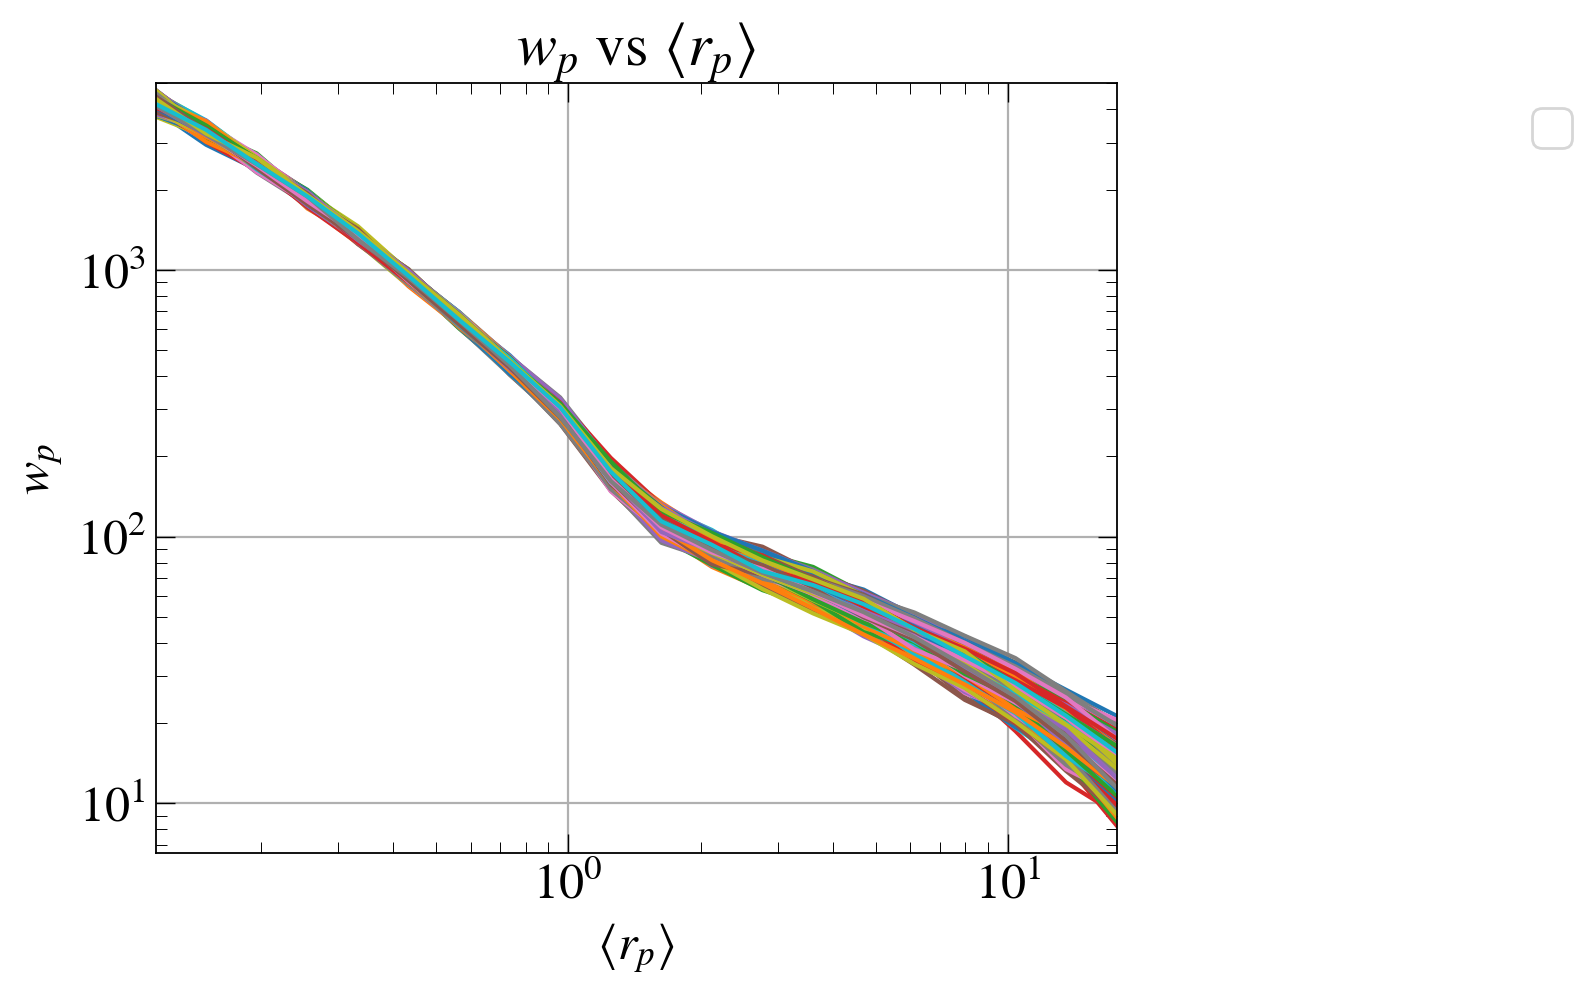

In [4]:
file = f"{data_dir}wp_ph000.npz"
data = np.load(file)
all_wp = data['wp_']
all_rp = data['rp_avg']
for i in range (1, 25):
    file = f"{data_dir}wp_ph{i:03d}.npz"
    data = np.load(file)
    all_wp = np.concatenate((all_wp, data['wp_']))
    all_rp = np.concatenate((all_rp, data['rp_avg']))
rp_thresh, wp_thresh, stdev_thresh = ct.error_data(all_rp, all_wp)
print(np.max(all_wp))
pg.plot_results(all_rp, all_wp, y_max= 5000, y_min = 6.5)

14.126779259829748 4207.27006848533


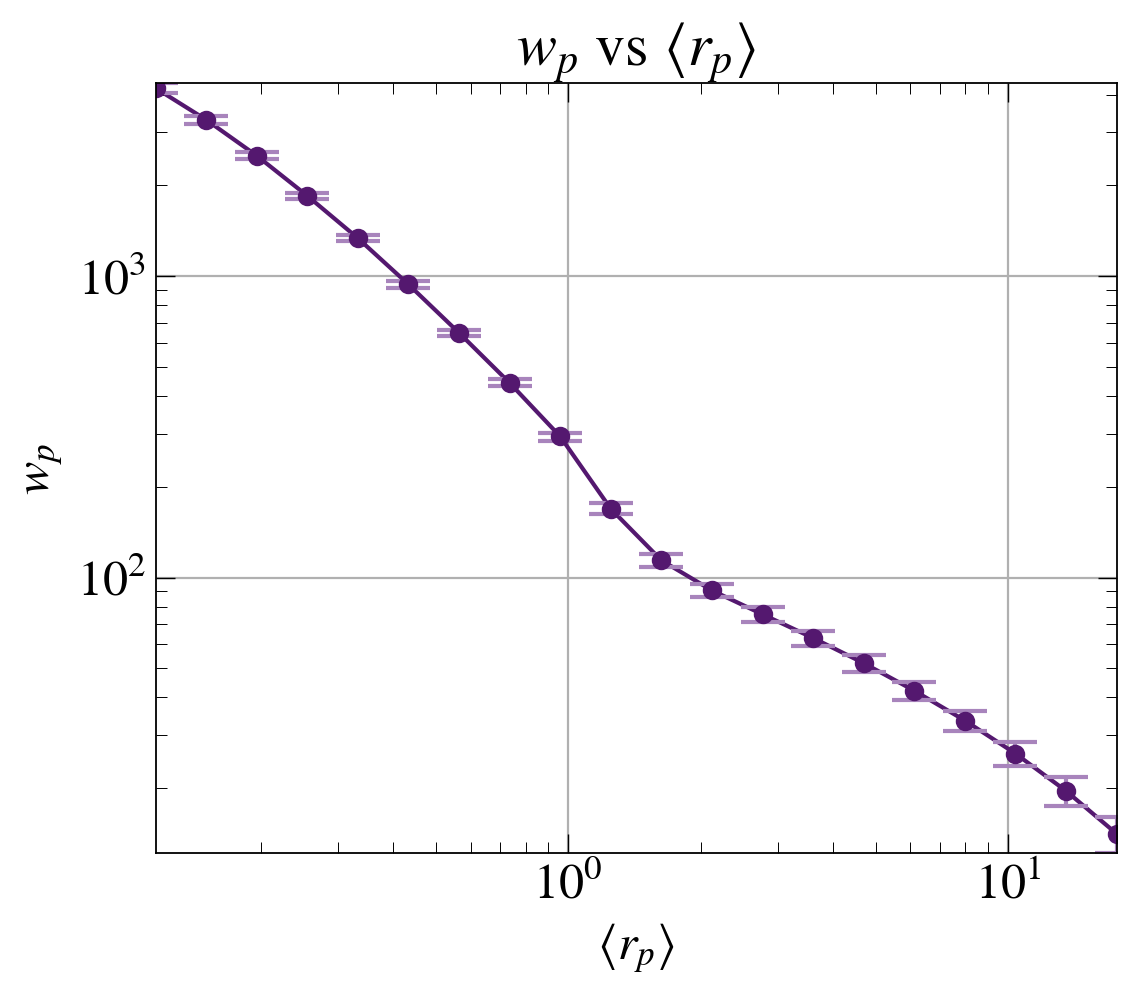

In [5]:
pg.wp_vs_rpavg(rp_thresh, wp_thresh, stdev_thresh)
plt.show()

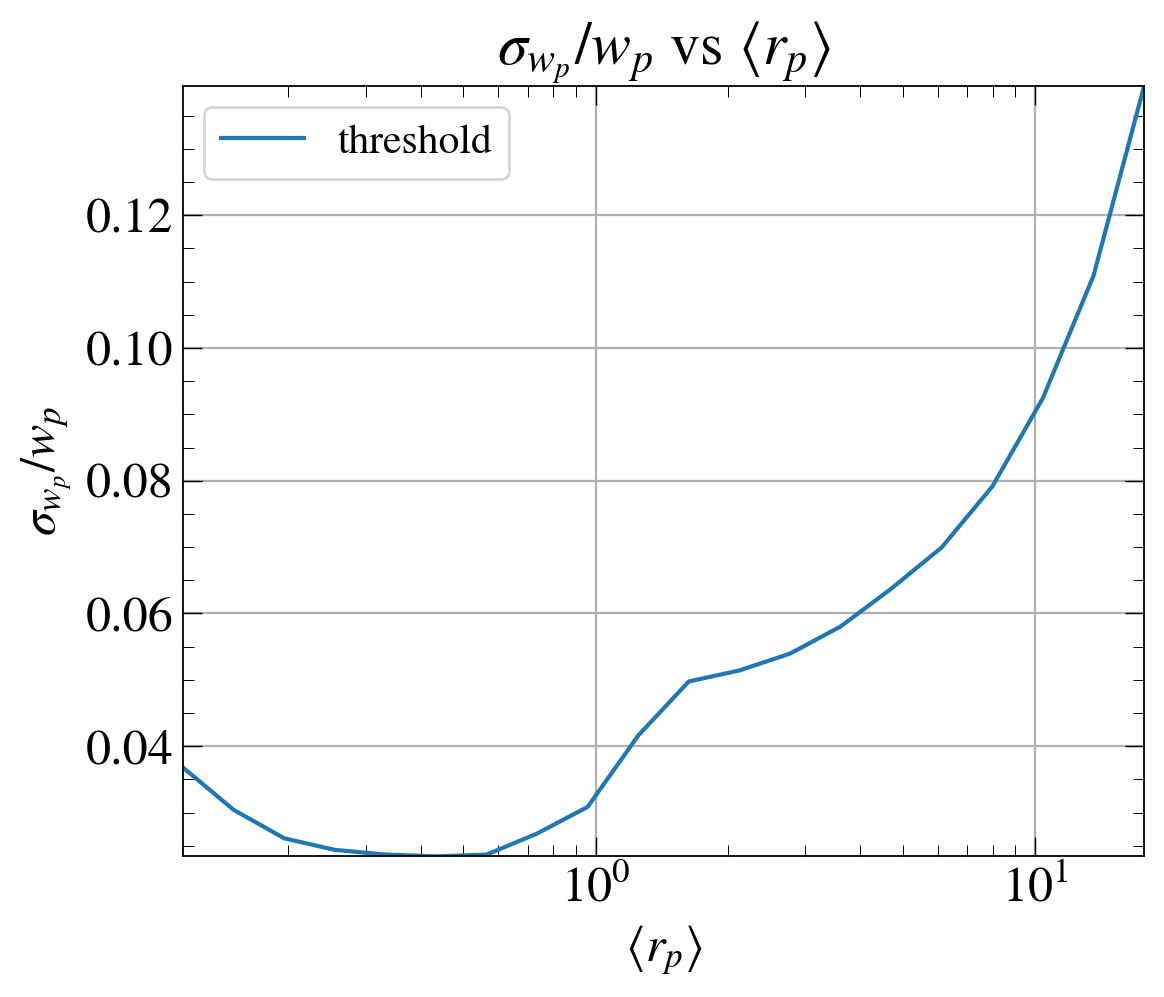

In [7]:
frac_err_thresh = pg.get_frac_err(stdev_thresh, wp_thresh)
pg.plot_frac_err([rp_thresh], [frac_err_thresh], labels = ['threshold'])

# Plotting comparison: w/ vs w/o cross-volume comparison

In [9]:
data_no_cross = np.load(f"{data_dir}wp_subvol_no_cross.npz")
wp_no_cross = data_no_cross['wp_all']
rp_no_cross = data_no_cross['rp_all']

14.126779259829748 4207.27006848533
12.691267588397666 4200.316500220683


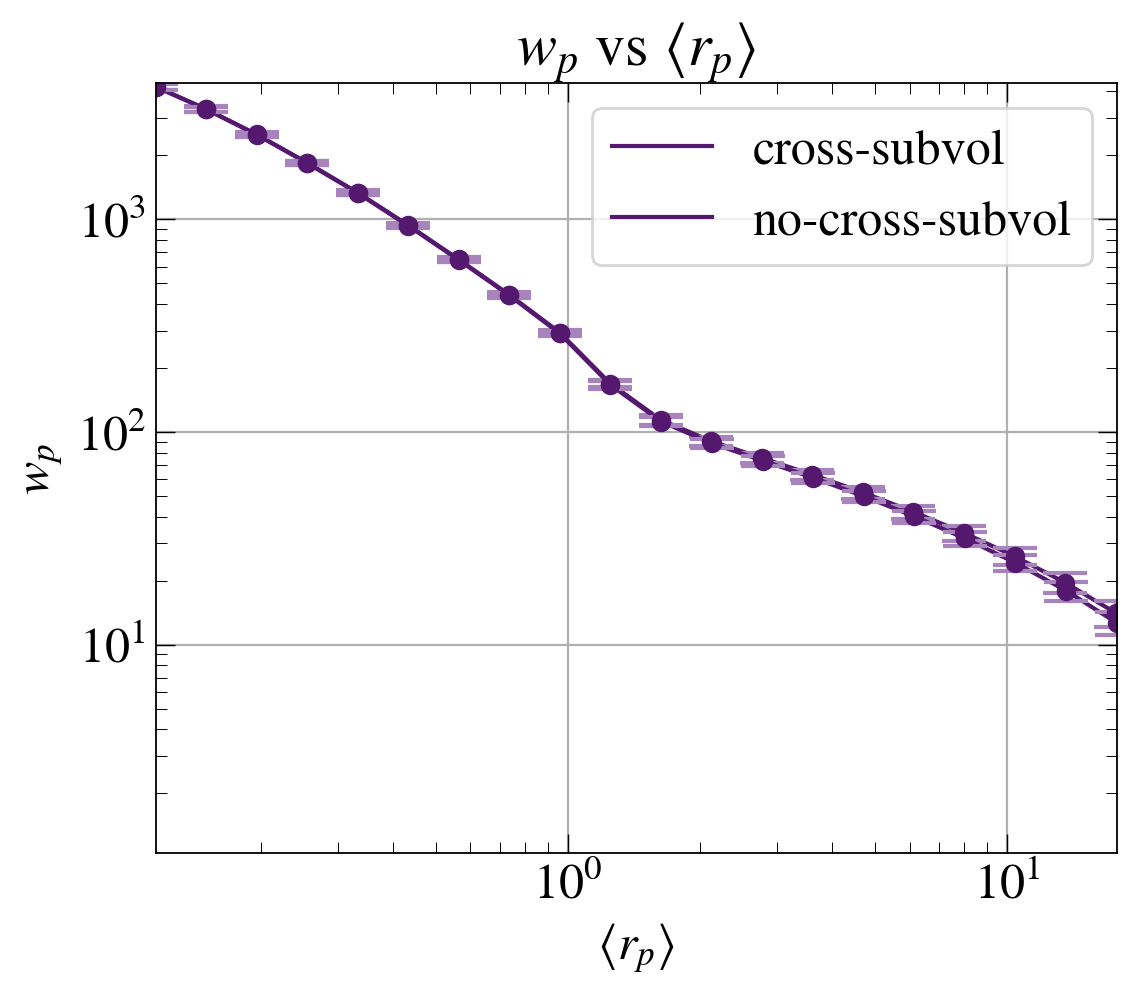

In [10]:
pg.wp_vs_rpavg(rp_thresh, wp_thresh, stdev_thresh, legend = 'cross-subvol')
rp_nc, wp_nc, stdev_nc = ct.error_data(rp_no_cross, wp_no_cross)
pg.wp_vs_rpavg(rp_nc, wp_nc, stdev_nc, legend = 'no-cross-subvol')
plt.legend()
plt.show()

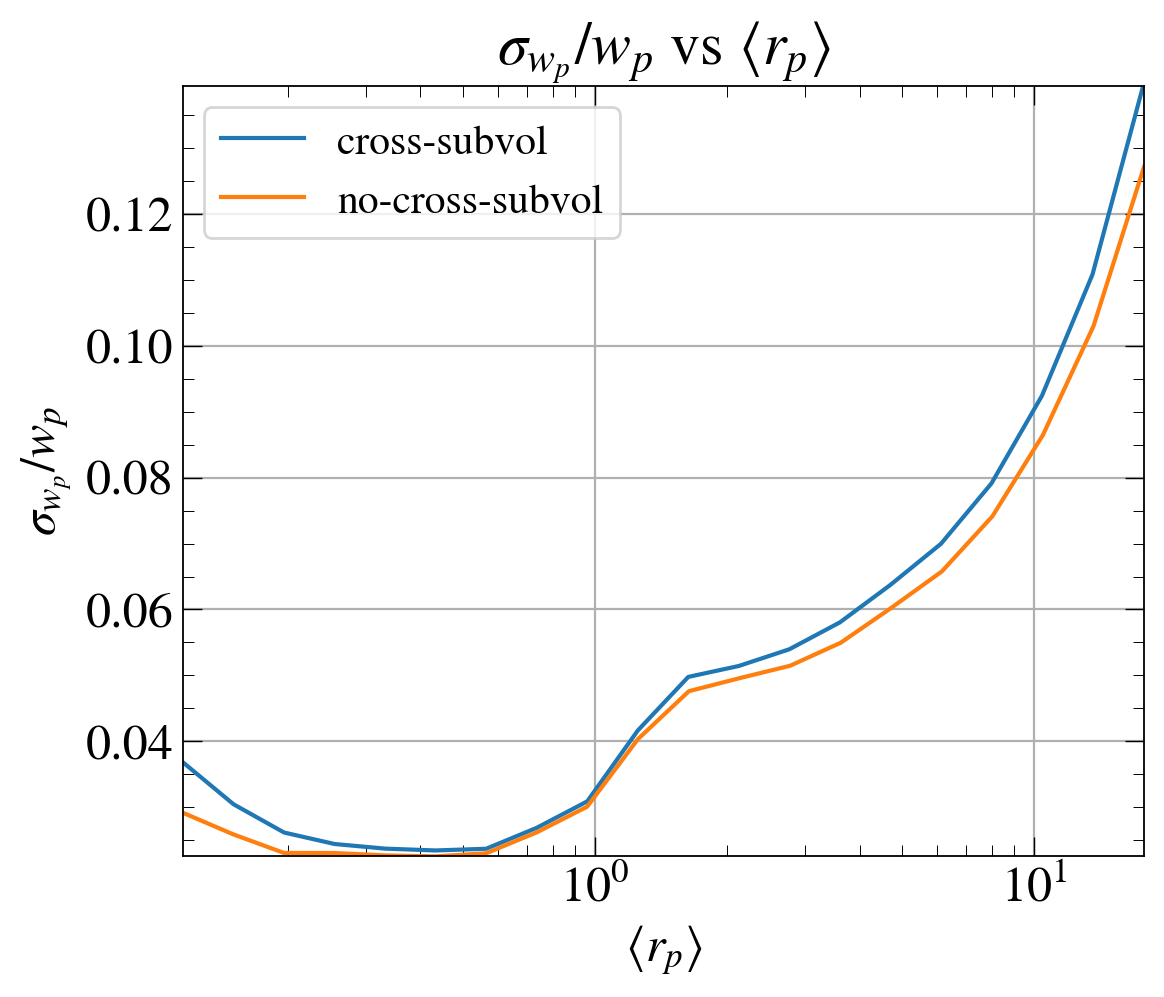

In [11]:
frac_err_nc = pg.get_frac_err(stdev_nc, wp_nc)
pg.plot_frac_err([rp_thresh, rp_nc], [frac_err_thresh, frac_err_nc], labels = ["cross-subvol", "no-cross-subvol"])

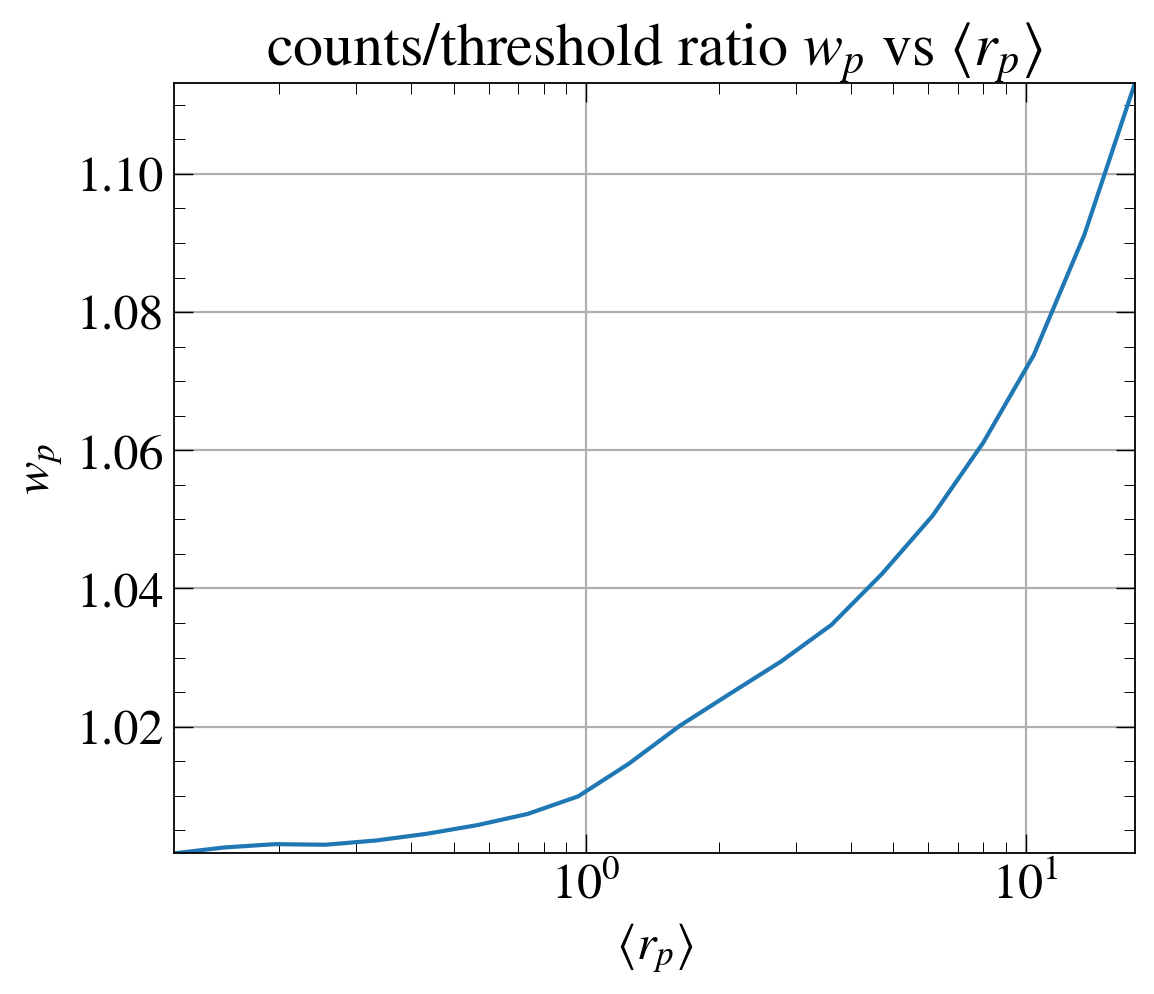

In [12]:
rpavg_ = all_rp
wp_ = all_wp
rpavg_mean_cross, wp_mean_cross, stdev_cross = ct.error_data(rpavg_, wp_)
rpavg_mean_no_cross, wp_mean_no_cross, stdev_no_cross = ct.error_data(rp_no_cross, wp_no_cross)
rp = (np.array(rpavg_mean_cross) + np.array(rpavg_mean_no_cross))/2
plt.plot(rp, np.array(wp_mean_cross)/np.array(wp_mean_no_cross))
plt.title(r'counts/threshold ratio $w_p$ vs $\langle r_p\rangle$')
plt.xlabel(r'$\langle r_p\rangle$')
plt.ylabel(r'$w_p$')
plt.xscale('log')